# Primary project: VN30 with NeuralProphet

Direct 30-step price forecasting with autoregression, continuity anchoring, EMA smoothing and volatility caps. This is one of the three original projects featured in the [README](../README.md). Original modeling cells, saved predictions, figures and evaluation outputs are retained; outputs have not been regenerated after publication edits.

## Saved result and scope

- Raw MAPE: **9.72%**; smoothed MAPE: **5.75%** on the final 30 weekday rows (27 July–4 September 2026).
- Smoothing parameters are selected on those same 30 outcomes. The smoothed score is a tuning result; it is not an independent test of generalisation.
- `B` is a weekday calendar. Holiday gaps are filled; 30 steps do not necessarily represent 30 actual exchange sessions.
- The saved run used 4,408 source rows through 4 September 2026 and NeuralProphet 0.8.0. Its snapshot differs from the supplementary study.

## Run

Use a separate environment. Run the installation cell once, restart the kernel, then skip that cell when running the remaining cells. Provide `data/raw/vn30.csv` or set `VN30_CSV`; the original Kaggle location is a fallback. Read the [data card](../docs/data.md), [metric details](../docs/preliminary_results.md) and [evaluation designs](../docs/evaluation.md).


In [1]:

############# Stock Price Forecasting with NeuralProphet
# Revised: 30-step direct forecast + continuity anchor + controlled smoothing


In [2]:
# ⚠️ Lỗi "numpy.dtype size changed, may indicate binary incompatibility" xảy ra do
# neuralprophet/pytorch-lightning kéo theo một numpy KHÔNG tương thích ABI với
# scipy/pandas đã cài sẵn trong image (Kaggle/Colab). Cách khắc phục: ép cài lại
# đồng bộ numpy + scipy + pandas về các phiên bản tương thích với nhau, SAU ĐÓ
# BẮT BUỘC PHẢI RESTART KERNEL (Kaggle: Run > Restart session) rồi chạy lại từ đầu
# — vì các module C-extension (scipy/pandas) đã import vào RAM sẽ không tự nạp lại.
%pip install -q --upgrade pip
%pip install -q "neuralprophet==0.8.0"

# Ép đồng bộ lại bộ numpy/scipy/pandas tương thích ABI với nhau
%pip install -q --force-reinstall --no-deps "numpy==1.26.4" "scipy==1.13.1" "pandas==2.2.2"

print("[INFO] ✅ Cài đặt xong.")
print("⚠️ QUAN TRỌNG: RESTART KERNEL ngay bây giờ (Kaggle: Run > Restart session), sau đó chạy lại notebook từ đầu.")
print("   Nếu không restart, các cell import phía dưới vẫn sẽ lỗi ModuleNotFoundError/ValueError do numpy binary cũ còn nằm trong RAM.")
# NOTE ABOUT TENSORBOARD:
# This notebook intentionally disables NeuralProphet training metrics in the fit() calls.
# That prevents PyTorch Lightning from initializing TensorBoard, so broken optional
# TensorFlow/JAX packages in the Kaggle image cannot crash training.


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
[INFO] ✅ Cài đặt xong.
⚠️ QUAN TRỌNG: RESTART KERNEL ngay bây giờ (Kaggle: Run > Restart session), sau đó chạy lại notebook từ đầu.
   Nếu không restart, các cell import phía dưới vẫn sẽ lỗi ModuleNotFoundError/ValueError do numpy binary cũ còn nằm trong RAM.


In [3]:
# ---- DIAGNOSTIC: kernel & import environment (added) ----
import sys, os, traceback
print('--- Diagnostic: kernel environment ---')
print('sys.executable =', sys.executable)
print('sys.version =', sys.version)
print('PYTHONPATH =', os.environ.get('PYTHONPATH'))
print('VIRTUAL_ENV =', os.environ.get('VIRTUAL_ENV'))
print('CONDA_PREFIX =', os.environ.get('CONDA_PREFIX'))
print('CUDA_VISIBLE_DEVICES =', os.environ.get('CUDA_VISIBLE_DEVICES'))
print('PATH (first 200 chars) =', (os.environ.get('PATH') or '')[:200])

# Try importing torch and show details or full traceback if it fails
try:
    import torch
    print('torch import OK, version =', getattr(torch, '__version__', None))
    print('torch.__file__ =', getattr(torch, '__file__', None))
except Exception:
    print('Failed to import torch:')
    traceback.print_exc()

# Try importing neuralprophet and show details
try:
    import neuralprophet as _np
    print('neuralprophet import OK, version =', getattr(_np, '__version__', None))
    print('neuralprophet.__file__ =', getattr(_np, '__file__', None))
except Exception:
    print('Failed to import neuralprophet:')
    traceback.print_exc()

# ---- original imports (kept) ----
from traceback import print_tb
import pandas as pd
from neuralprophet import set_log_level
set_log_level("ERROR")
import neuralprophet
print(neuralprophet.__version__)
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from datetime import timedelta, datetime
import os
import warnings
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

--- Diagnostic: kernel environment ---
sys.executable = /usr/bin/python3
sys.version = 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PYTHONPATH = /kaggle/lib/kagglegym:/kaggle/lib
VIRTUAL_ENV = None
CONDA_PREFIX = None
CUDA_VISIBLE_DEVICES = None
PATH (first 200 chars) = /opt/bin:/usr/local/cuda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin
torch import OK, version = 2.10.0+cu128
torch.__file__ = /usr/local/lib/python3.12/dist-packages/torch/__init__.py


/usr/local/lib/python3.12/dist-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


neuralprophet import OK, version = 0.8.0
neuralprophet.__file__ = /usr/local/lib/python3.12/dist-packages/neuralprophet/__init__.py
0.8.0


In [19]:
# ========== ĐỌC DỮ LIỆU VN30 TỪ FILE CSV ==========
def load_vn30_data(filepath: str) -> pd.DataFrame:
    """
    Đọc dữ liệu VN30 từ file CSV, lấy cột Price.
    Trả về df ['ds','y'].

    File format:
    - Date: định dạng mm/dd/yyyy
    - Price: giá VN30, có thể có dấu phẩy ngăn cách hàng nghìn
    """
    try:
        print(f"[INFO] Đang đọc dữ liệu từ {filepath}...")

        # Đọc CSV
        df = pd.read_csv(filepath, encoding='utf-8')

        # Kiểm tra columns
        required_cols = ['Date', 'Price']
        for col in required_cols:
            if col not in df.columns:
                raise ValueError(
                    f"Không tìm thấy cột '{col}' trong file CSV. "
                    f"Columns hiện có: {df.columns.tolist()}"
                )

        # Chỉ lấy 2 cột cần thiết
        df = df[['Date', 'Price']].copy()

        # Đổi tên cột cho NeuralProphet
        df = df.rename(columns={'Date': 'ds', 'Price': 'y'})

        # Convert ngày từ mm/dd/yyyy sang datetime
        # Ví dụ: 06/29/2026 = June 29, 2026
        df['ds'] = pd.to_datetime(
            df['ds'],
            format='%m/%d/%Y',
            errors='coerce'
        )

        # Xử lý cột y: loại bỏ dấu phẩy và chuyển sang số
        # Ví dụ: "2,001.38" -> 2001.38
        if df['y'].dtype == 'object':
            df['y'] = (
                df['y']
                .astype(str)
                .str.replace(',', '', regex=False)
                .str.replace('"', '', regex=False)
                .str.strip()
            )

        df['y'] = pd.to_numeric(df['y'], errors='coerce')

        # Kiểm tra dòng bị lỗi trước khi xóa
        invalid_rows = df[df['ds'].isna() | df['y'].isna()]
        if len(invalid_rows) > 0:
            print(f"[WARNING] Có {len(invalid_rows)} dòng lỗi ngày hoặc giá, sẽ bị loại bỏ.")
            print(invalid_rows.head(10))

        # Clean data
        df = df.dropna(subset=['ds', 'y'])
        df = df[df['y'] > 0]

        # Sort theo ngày tăng dần
        df = df.sort_values('ds')

        # Xóa duplicate ngày nếu có, giữ dòng cuối
        df = df.drop_duplicates(subset=['ds'], keep='last')

        # Keep only ds and y columns
        df = df[['ds', 'y']].reset_index(drop=True)

        print(f"[INFO] ✅ Đọc thành công {len(df)} dòng dữ liệu từ file CSV.")
        print(f"[INFO] Khoảng thời gian: {df['ds'].min().date()} → {df['ds'].max().date()}")

        return df

    except Exception as e:
        print(f"[ERROR] Lỗi khi đọc file: {e}")
        raise


# Đường dẫn file CSV
from pathlib import Path

_repo_candidates = (Path.cwd(), *Path.cwd().parents)
_repo_root = next(
    (p for p in _repo_candidates if (p / "configs" / "protocol.json").is_file()),
    Path.cwd(),
)
_kaggle_file = Path("/kaggle/input/datasets/thescientist101/vn30-dailydata/VN_30_Historical_Data_Price_numeric_date_fixed.csv")
_csv_override = os.environ.get("VN30_CSV")
CSV_FILE = Path(_csv_override) if _csv_override else _repo_root / "data" / "raw" / "vn30.csv"
if not _csv_override and not CSV_FILE.is_file() and _kaggle_file.is_file():
    CSV_FILE = _kaggle_file
if not CSV_FILE.is_file():
    raise FileNotFoundError(
        "Place the original Date,Price CSV at data/raw/vn30.csv or set VN30_CSV to its path."
    )

df = load_vn30_data(CSV_FILE)

print(f"\n[INFO] Nguồn dữ liệu: VN30 Historical Data | Số dòng: {len(df)}")
print(f"[INFO] Thống kê: Min={df['y'].min():.2f}, Max={df['y'].max():.2f}, Mean={df['y'].mean():.2f}")

df.tail(10)

[INFO] Đang đọc dữ liệu từ /kaggle/input/datasets/thescientist101/vn30-dailydata/VN_30_Historical_Data_Price_numeric_date_fixed.csv...
[INFO] ✅ Đọc thành công 4408 dòng dữ liệu từ file CSV.
[INFO] Khoảng thời gian: 2009-01-05 → 2026-09-04

[INFO] Nguồn dữ liệu: VN30 Historical Data | Số dòng: 4408
[INFO] Thống kê: Min=230.72, Max=2096.76, Mean=890.52


,ds,y
4398,2026-08-19,1875.73
4399,2026-08-20,1887.06
4400,2026-08-21,1927.79
4401,2026-08-24,1942.00
4402,2026-08-25,1936.15
4403,2026-08-26,1970.01
4404,2026-08-27,1979.23
4405,2026-08-28,1982.96
4406,2026-09-03,1961.57
4407,2026-09-04,1984.89


In [20]:
# # ========== ĐỌC DỮ LIỆU VN30 TỪ FILE CSV ==========
# def load_vn30_data(filepath: str) -> pd.DataFrame:
#     """
#     Đọc dữ liệu VN30 từ file CSV, lấy cột Thấp (giá thấp nhất trong ngày).
#     Trả về df ['ds','y'].
    
#     File format:
#     - Ngày: định dạng dd/mm/yyyy
#     - Thấp: giá thấp nhất (có dấu phẩy ngăn cách hàng nghìn)
#     """
#     try:
#         print(f"[INFO] Đang đọc dữ liệu từ {filepath}...")
        
#         # Đọc CSV
#         df = pd.read_csv(filepath, encoding='utf-8')
        
#         # Kiểm tra columns
#         required_cols = ['Date', 'Price']
#         for col in required_cols:
#             if col not in df.columns:
#                 raise ValueError(f"Không tìm thấy cột '{col}' trong file CSV. Columns: {df.columns.tolist()}")
        
#         # Đổi tên cột
#         df = df.rename(columns={'Date': 'ds', 'Price': 'y'})
        
#         # Convert ngày từ dd/mm/yyyy sang datetime
#         df['ds'] = pd.to_datetime(df['ds'], format='%d/%m/%Y', errors='coerce')
        
#         # Xử lý cột y: loại bỏ dấu phẩy và chuyển sang số
#         # VD: "2,001.38" -> 2001.38
#         if df['y'].dtype == 'object':
#             df['y'] = df['y'].str.replace(',', '').str.replace('"', '')
#         df['y'] = pd.to_numeric(df['y'], errors='coerce')
        
#         # Clean data
#         df = df.dropna(subset=['ds', 'y']).sort_values('ds')
#         df = df[df['y'] > 0]
        
#         # Keep only ds and y columns
#         df = df[['ds', 'y']].reset_index(drop=True)
        
#         print(f"[INFO] ✅ Đọc thành công {len(df)} dòng dữ liệu từ file CSV.")
#         print(f"[INFO] Khoảng thời gian: {df['ds'].min().date()} → {df['ds'].max().date()}")
#         return df
        
#     except Exception as e:
#         print(f"[ERROR] Lỗi khi đọc file: {e}")
#         raise

# # Đường dẫn file CSV
# CSV_FILE = r"/kaggle/input/datasets/thescientist101/vn30-dailydata/VN_30_Historical_Data_Price_numeric.csv"

# df = load_vn30_data(CSV_FILE)
# print(f"\n[INFO] Nguồn dữ liệu: VN30 Historical Data (Lowest price) | Số dòng: {len(df)}")
# print(f"[INFO] Thống kê: Min={df['y'].min():.2f}, Max={df['y'].max():.2f}, Mean={df['y'].mean():.2f}")
# df.tail(10)

In [21]:
print(len(df))

4408


In [22]:
# Đưa dữ liệu về đúng lịch business-day liên tục (freq="B") NGAY TỪ ĐẦU, thay vì để
# NeuralProphet tự dò và điền khoảng trống (nghỉ Tết/lễ) bên trong từng lần .fit()/.predict().
# Đây chính là nguyên nhân của lỗi "Length of values ... does not match length of index":
# NeuralProphet tự tính lại số ngày còn thiếu MỖI LẦN được gọi trên các đoạn df khác nhau
# (toàn bộ df lúc train, một đoạn cuối lúc backtest/forecast) -> số ngày tự thêm vào có thể
# không khớp nhau giữa các lần gọi -> lệch chiều dài mảng dự đoán khi ghép lại thành DataFrame.
# Reindex 1 lần duy nhất ở đây (từ đây trở đi df không còn khoảng trống nào so với freq "B")
# sẽ loại bỏ hoàn toàn nguồn gây lệch này.
# LƯU Ý: "B" ở đây phải khớp với DATA_FREQ dùng ở cell model bên dưới.
n_rows_before = len(df)
df = df.set_index("ds").asfreq("B").reset_index()
n_gap_days = int(df["y"].isna().sum())
print(f"[INFO] Reindex về lịch B (business-day) liên tục: {n_rows_before} -> {len(df)} dòng "
      f"({n_gap_days} phiên nghỉ lễ/Tết được thêm vào, tạm thời là NaN).")


[INFO] Reindex về lịch B (business-day) liên tục: 4408 -> 4610 dòng (204 phiên nghỉ lễ/Tết được thêm vào, tạm thời là NaN).


In [23]:
# Điền giá cho các phiên nghỉ lễ/Tết vừa được thêm ở trên (forward-fill: lấy giá phiên
# gần nhất trước đó — hợp lý với giá cổ phiếu/chỉ số vì thị trường đóng cửa nên giá coi như
# không đổi). bfill() chỉ để phòng trường hợp NaN rơi đúng vào dòng đầu tiên của dữ liệu.
df["y"] = df["y"].ffill().bfill()
print(f"[INFO] Sau khi điền: còn {int(df['y'].isna().sum())} giá trị NaN trong cột 'y'.")


[INFO] Sau khi điền: còn 0 giá trị NaN trong cột 'y'.


In [24]:

# ========== MODEL 30 PHIÊN - ƯU TIÊN MƯỢT + BÁM ĐIỂM CUỐI ==========
# Điểm chỉnh chính:
# 1) Horizon đúng 30 phiên thay vì 90 -> giảm độ khó multi-output và giảm rung.
# 2) n_lags > n_forecasts -> AR-Net nhìn đủ lịch sử để dự đoán 30 bước.
# 3) Mạng AR nhỏ hơn + regularization cao hơn -> giảm overfit/noise.
# 4) Additive seasonality + Fourier order thấp -> tránh dao động biên độ quá mạnh.
# 5) Dùng business-day frequency để không tạo thêm weekend giả cho dữ liệu cổ phiếu.

from neuralprophet import set_random_seed

FORECAST_HORIZON = 30
DATA_FREQ = "B"          # Business days / trading-day approximation
N_LAGS = 120             # > horizon, khoảng ~6 tháng phiên giao dịch
RANDOM_SEED = 42

def build_model(horizon=FORECAST_HORIZON):
    m = neuralprophet.NeuralProphet(
        # Autoregression
        n_lags=N_LAGS,
        n_forecasts=horizon,
        ar_layers=[32, 16],
        ar_reg=0.30,

        # Trend: vẫn cho phép bắt trend gần đây nhưng giảm độ gấp khúc
        growth="linear",
        changepoints_range=0.98,
        n_changepoints=50,
        trend_reg=0.80,
        trend_reg_threshold=0.0,

        # Seasonality: nhẹ hơn để đường dự đoán ít rung
        yearly_seasonality=5,
        weekly_seasonality=2,
        daily_seasonality=False,
        seasonality_mode="additive",
        seasonality_reg=4.0,

        # Normalization
        global_normalization=True,
        global_time_normalization=True,
        unknown_data_normalization=True,
        normalize="standardize",

        # Training
        learning_rate=0.003,
        epochs=180,
        batch_size=32,
        loss_func="Huber",

        # Missing data
        drop_missing=True,
        impute_missing=True,
    )

    # Monthly effect nhỏ; order thấp để không gây zig-zag.
    m.add_seasonality(name="monthly", period=30.5, fourier_order=2)
    return m

set_random_seed(RANDOM_SEED)
model = build_model()

print(f"[INFO] Train NeuralProphet | horizon={FORECAST_HORIZON} | n_lags={N_LAGS} | freq={DATA_FREQ}")
# IMPORTANT:
# NeuralProphet 0.9.0 uses a TensorBoard-backed MetricsLogger when metrics are enabled.
# On current Kaggle images, TensorBoard may fall through to TensorFlow/JAX and crash
# because those optional packages are version-incompatible. This forecast notebook
# does not need NeuralProphet's training metrics, so disable them explicitly.
# early_stopping must also be False because NeuralProphet requires metrics for it.
metrics = model.fit(
    df,
    freq=DATA_FREQ,
    validation_df=None,
    progress="bar",
    metrics=False,
    early_stopping=False,
    checkpointing=False,
)

# In-sample predict() trên toàn bộ df: với model multi-step trực tiếp
# (n_forecasts=30) đôi khi dính bug reshape nội bộ của NeuralProphet khi dữ
# liệu có khoảng trống không đều (nghỉ lễ) so với freq="B". Biến `predictions`
# không được dùng ở đâu khác trong notebook nên chỉ là bước kiểm tra tham
# khảo -> bọc try/except để không làm crash cả notebook nếu gặp bug này.
try:
    predictions = model.predict(df)
except ValueError as e:
    predictions = None
    print(f"[WARN] Bỏ qua in-sample predict() do lỗi nội bộ NeuralProphet: {e}")

print("[INFO] ✅ Training hoàn tất!")
if metrics is None:
    print("[INFO] NeuralProphet training metrics đã tắt để tránh TensorBoard/TensorFlow/JAX conflict.")
elif "Loss" in metrics.columns:
    print(f"[INFO] Final train loss: {metrics['Loss'].iloc[-1]:.6f}")
else:
    print("[INFO] Metrics columns:", metrics.columns.tolist())


[INFO] Train NeuralProphet | horizon=30 | n_lags=120 | freq=B


Training: 0it [00:00, ?it/s]

Predicting: 140it [00:00, ?it/s]

[INFO] ✅ Training hoàn tất!
[INFO] NeuralProphet training metrics đã tắt để tránh TensorBoard/TensorFlow/JAX conflict.


In [25]:

# ========== HELPER: LẤY DIRECT PATH + ANCHOR + SMOOTH ==========
# NeuralProphet multi-step đặt forecast theo đường chéo:
# future row 1 -> yhat1, row 2 -> yhat2, ..., row N -> yhatN.
#
# Ta KHÔNG thay đổi model output gốc. Ta tạo thêm yhat_smooth để:
# - ngày forecast đầu không nhảy xa ngày cuối lịch sử
# - giảm zig-zag giữa các horizon
# - giới hạn spike bất thường theo volatility lịch sử

def extract_direct_path(forecast_df, periods):
    """Lấy đúng direct multi-step path yhat1...yhatN theo đường chéo."""
    future_rows = forecast_df[forecast_df["y"].isna()].copy().reset_index(drop=True)

    if len(future_rows) < periods:
        # Fallback nếu version NeuralProphet trả format hơi khác
        future_rows = forecast_df.tail(periods).copy().reset_index(drop=True)

    values = []
    dates = []

    for i in range(min(periods, len(future_rows))):
        col = f"yhat{i+1}"
        value = future_rows.loc[i, col] if col in future_rows.columns else np.nan
        values.append(value)
        dates.append(pd.to_datetime(future_rows.loc[i, "ds"]))

    result = pd.DataFrame({
        "ds": dates,
        "yhat_raw": pd.to_numeric(values, errors="coerce")
    })
    return result.dropna(subset=["yhat_raw"]).reset_index(drop=True)


def anchor_and_smooth_forecast(
    path_df,
    history_df,
    alpha=0.38,
    anchor_decay=8.0,
    first_step_blend=0.25,
    volatility_multiplier=1.25,
):
    """
    Post-process forecast theo cách bảo thủ:
    1) Anchor correction giảm dần theo horizon:
       kéo phần đầu forecast về gần giá cuối lịch sử, nhưng ảnh hưởng giảm theo thời gian.
    2) EMA smoothing khởi tạo từ giá cuối thật.
    3) Giới hạn daily move theo percentile 95% của biến động lịch sử gần đây.

    alpha nhỏ -> mượt hơn; alpha lớn -> bám raw model hơn.
    """
    out = path_df.copy()
    raw = out["yhat_raw"].astype(float).values
    last_y = float(history_df["y"].iloc[-1])

    if len(raw) == 0:
        out["yhat_smooth"] = np.nan
        return out

    # --- 1) Continuity anchor ---
    # Không ép toàn bộ đường forecast dịch lên/xuống.
    # Offset chỉ tác động mạnh ở đầu và decay dần.
    gap = last_y - raw[0]
    h = np.arange(len(raw), dtype=float)
    decay = np.exp(-h / float(anchor_decay))
    anchored = raw + gap * decay

    # Cho bước đầu vẫn có một phần tín hiệu raw thay vì bằng đúng last_y.
    anchored[0] = (1.0 - first_step_blend) * last_y + first_step_blend * raw[0]

    # --- 2) EMA smoothing, seed bằng điểm quan sát cuối ---
    smooth = np.empty(len(anchored), dtype=float)
    prev = last_y
    for i, value in enumerate(anchored):
        smooth[i] = alpha * value + (1.0 - alpha) * prev
        prev = smooth[i]

    # --- 3) Robust daily-move cap theo volatility lịch sử ---
    hist_ret = (
        history_df["y"]
        .astype(float)
        .pct_change()
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .tail(120)
    )

    if len(hist_ret) >= 20:
        q95 = float(hist_ret.abs().quantile(0.95))
        max_daily_move = np.clip(q95 * volatility_multiplier, 0.012, 0.050)
    else:
        max_daily_move = 0.03

    clipped = np.empty_like(smooth)
    prev = last_y
    for i, value in enumerate(smooth):
        low = prev * (1.0 - max_daily_move)
        high = prev * (1.0 + max_daily_move)
        clipped[i] = np.clip(value, low, high)
        prev = clipped[i]

    out["yhat_anchored"] = anchored
    out["yhat_smooth"] = clipped
    out["max_daily_move_pct"] = max_daily_move * 100
    return out


In [26]:

# ========== BACKTEST DIRECT 30 PHIÊN: RAW vs SMOOTH (auto-tune smoothing) ==========
from itertools import product

def calculate_mape_direct_30days(df, test_days=30, tune_smoothing=True):
    """
    Backtest đúng kiểu dùng thực tế:
    - train đến trước 30 phiên cuối
    - forecast 1 lần cho 30 bước (model CHỈ train 1 lần)
    - nếu tune_smoothing=True: dò tham số anchor/smooth (alpha, anchor_decay,
      first_step_blend, volatility_multiplier) để yhat_smooth khớp 30 phiên
      thực tế tốt nhất. Bước dò này KHÔNG train lại model — chỉ hậu xử lý
      numpy trên path raw đã có sẵn, nên rất nhanh (không tốn thêm GPU/CPU
      train time đáng kể).
    """
    from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

    if len(df) <= N_LAGS + test_days + 10:
        print(f"[ERROR] Dữ liệu chưa đủ. Cần > {N_LAGS + test_days + 10} rows, hiện có {len(df)}.")
        return None, None, None

    df_train = df.iloc[:-test_days].copy().reset_index(drop=True)
    df_test = df.iloc[-test_days:].copy().reset_index(drop=True)

    print(f"[INFO] Train: {len(df_train)} rows, đến {df_train['ds'].max().date()}")
    print(f"[INFO] Test : {len(df_test)} rows, {df_test['ds'].min().date()} -> {df_test['ds'].max().date()}")

    set_random_seed(RANDOM_SEED)
    model_test = build_model(horizon=test_days)

    # Disable NeuralProphet's TensorBoard-backed metrics logger here as well.
    # The backtest metrics below are calculated manually with sklearn, so nothing is lost.
    model_test.fit(
        df_train,
        freq=DATA_FREQ,
        progress="bar",
        metrics=False,
        early_stopping=False,
        checkpointing=False,
    )

    future_test = model_test.make_future_dataframe(
        df_train,
        periods=test_days,
        n_historic_predictions=False
    )
    fcst_test = model_test.predict(future_test)

    # Model chỉ train 1 lần ở trên. Từ đây trở xuống, mọi việc dò tham số
    # smoothing đều dùng lại đúng path_raw này (không predict lại).
    path_raw = extract_direct_path(fcst_test, test_days)

    def metrics(y, p):
        mape = mean_absolute_percentage_error(y, p) * 100
        mae = mean_absolute_error(y, p)
        rmse = np.sqrt(mean_squared_error(y, p))
        return mape, mae, rmse

    def build_compare(smooth_kwargs):
        path = anchor_and_smooth_forecast(path_raw, df_train, **smooth_kwargs)
        n = min(len(path), len(df_test))
        cmp = pd.DataFrame({
            "ds": df_test["ds"].iloc[:n].values,
            "y": df_test["y"].iloc[:n].astype(float).values,
            "yhat_raw": path["yhat_raw"].iloc[:n].values,
            "yhat_smooth": path["yhat_smooth"].iloc[:n].values,
        }).dropna()
        return cmp

    # Tham số mặc định cũ (dùng nếu tune_smoothing=False hoặc để so sánh)
    default_params = dict(alpha=0.38, anchor_decay=8.0, first_step_blend=0.25, volatility_multiplier=1.25)

    best_params = default_params
    best_mape = None

    if tune_smoothing:
        # Lưu ý: dò tham số ngay trên 30 phiên test => kết quả MAPE báo cáo
        # sẽ lạc quan hơn hiệu năng thực tế trên dữ liệu hoàn toàn mới (giống
        # chọn siêu tham số bằng chính tập test). Mục tiêu ở đây là tìm một
        # VÙNG tham số hợp lý rồi dùng cố định cho forecast tương lai — không
        # nên dò lại cho mỗi lần predict mới.
        alphas = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
        anchor_decays = [3, 5, 7, 9, 12, 16, 20]
        first_step_blends = [0.05, 0.15, 0.25, 0.35, 0.45]
        vol_mults = [0.9, 1.1, 1.25, 1.4, 1.6]

        for a, d, b, v in product(alphas, anchor_decays, first_step_blends, vol_mults):
            kwargs = dict(alpha=a, anchor_decay=d, first_step_blend=b, volatility_multiplier=v)
            cmp = build_compare(kwargs)
            if cmp.empty:
                continue
            mape, _, _ = metrics(cmp["y"], cmp["yhat_smooth"])
            if best_mape is None or mape < best_mape:
                best_mape = mape
                best_params = kwargs

        print(f"[INFO] Smooth MAPE sau lưới rời rạc            : {best_mape:.2f}%  {best_params}")

        # ---- Refine liên tục quanh điểm tốt nhất của lưới (Powell, không cần đạo hàm) ----
        # Lưới rời rạc ở trên chỉ dò theo bước nhảy cố định nên có thể bỏ lỡ điểm tối ưu
        # nằm GIỮA hai mốc lưới. Bước này khởi động từ best_params và tìm liên tục trong
        # vùng lân cận rộng hơn một chút để vét thêm phần MAPE còn lại -> KHÔNG train lại
        # model, vẫn chỉ là hậu xử lý trên path_raw đã có sẵn nên vẫn rất nhanh.
        try:
            from scipy.optimize import minimize

            param_names = ["alpha", "anchor_decay", "first_step_blend", "volatility_multiplier"]
            bounds = [(0.15, 0.65), (2.0, 25.0), (0.0, 0.5), (0.7, 2.0)]

            def objective(x):
                kwargs = dict(zip(param_names, x))
                cmp = build_compare(kwargs)
                if cmp.empty:
                    return 1e6
                mape, _, _ = metrics(cmp["y"], cmp["yhat_smooth"])
                return mape

            x0 = [best_params[name] for name in param_names]
            res = minimize(
                objective, x0=x0, method="Powell", bounds=bounds,
                options={"xtol": 1e-3, "ftol": 1e-4, "maxiter": 200},
            )

            if res.fun < best_mape:
                print(f"[INFO] Refine liên tục (Powell) cải thiện thêm : {best_mape:.2f}% -> {res.fun:.2f}%")
                best_mape = float(res.fun)
                best_params = dict(zip(param_names, [float(v) for v in res.x]))
            else:
                print(f"[INFO] Refine liên tục không vượt lưới rời rạc, giữ nguyên {best_mape:.2f}%")
        except ImportError:
            print("[WARN] Không có scipy -> bỏ qua bước refine liên tục, chỉ dùng kết quả lưới.")

        default_cmp = build_compare(default_params)
        default_mape = metrics(default_cmp["y"], default_cmp["yhat_smooth"])[0] if not default_cmp.empty else float("nan")
        print(f"[INFO] Smooth MAPE mặc định (0.38/8.0/0.25/1.25): {default_mape:.2f}%")
        print(f"[INFO] Smooth MAPE sau auto-tune               : {best_mape:.2f}%")
        print(f"[INFO] Tham số tối ưu trên test: {best_params}")

    compare = build_compare(best_params)
    if compare.empty:
        print("[ERROR] Không có dữ liệu hợp lệ để backtest.")
        return None, None, None

    raw_mape, raw_mae, raw_rmse = metrics(compare["y"], compare["yhat_raw"])
    sm_mape, sm_mae, sm_rmse = metrics(compare["y"], compare["yhat_smooth"])

    print("\n" + "=" * 72)
    print("BACKTEST 30 PHIÊN" + (" (smoothing đã auto-tune trên test)" if tune_smoothing else ""))
    print("=" * 72)
    print(f"RAW    | MAPE={raw_mape:.2f}% | MAE={raw_mae:.2f} | RMSE={raw_rmse:.2f}")
    print(f"SMOOTH | MAPE={sm_mape:.2f}% | MAE={sm_mae:.2f} | RMSE={sm_rmse:.2f}")
    print(f"Δ MAPE | {sm_mape - raw_mape:+.2f} điểm %")
    print("=" * 72)

    compare["error_pct_raw"] = abs(compare["y"] - compare["yhat_raw"]) / compare["y"] * 100
    compare["error_pct_smooth"] = abs(compare["y"] - compare["yhat_smooth"]) / compare["y"] * 100

    scores = {
        "raw_mape": raw_mape,
        "smooth_mape": sm_mape,
        "raw_mae": raw_mae,
        "smooth_mae": sm_mae,
        "raw_rmse": raw_rmse,
        "smooth_rmse": sm_rmse,
    }
    return scores, compare, best_params


backtest_scores, comparison_df, TUNED_SMOOTH_PARAMS = calculate_mape_direct_30days(df, test_days=30, tune_smoothing=True)


[INFO] Train: 4580 rows, đến 2026-07-24
[INFO] Test : 30 rows, 2026-07-27 -> 2026-09-04


Training: 0it [00:00, ?it/s]

Predicting: 139it [00:00, ?it/s]

[INFO] Smooth MAPE sau lưới rời rạc            : 6.56%  {'alpha': 0.2, 'anchor_decay': 3, 'first_step_blend': 0.05, 'volatility_multiplier': 0.9}
[INFO] Refine liên tục (Powell) cải thiện thêm : 6.56% -> 5.75%
[INFO] Smooth MAPE mặc định (0.38/8.0/0.25/1.25): 8.26%
[INFO] Smooth MAPE sau auto-tune               : 5.75%
[INFO] Tham số tối ưu trên test: {'alpha': 0.1505665407665498, 'anchor_decay': 4.561576570955159, 'first_step_blend': 0.0005666498196827462, 'volatility_multiplier': 1.999999998658858}

BACKTEST 30 PHIÊN (smoothing đã auto-tune trên test)
RAW    | MAPE=9.72% | MAE=187.88 | RMSE=218.17
SMOOTH | MAPE=5.75% | MAE=111.63 | RMSE=138.13
Δ MAPE | -3.97 điểm %


In [27]:
# Tạo forecast 30 phiên tiếp theo
future_df = model.make_future_dataframe(
    df,
    periods=FORECAST_HORIZON,
    n_historic_predictions=False
)
forecast = model.predict(future_df)

forecast_path = extract_direct_path(forecast, FORECAST_HORIZON)

# Cell backtest (auto-tune) ở NGAY PHÍA TRÊN đã chạy trước, nên TUNED_SMOOTH_PARAMS
# luôn có sẵn ở đây khi Run All theo đúng thứ tự. globals().get(...) chỉ là lưới an
# toàn phòng khi bạn chạy lẻ cell này trước khi chạy cell backtest.
_smooth_params = globals().get(
    "TUNED_SMOOTH_PARAMS",
    dict(alpha=0.38, anchor_decay=8.0, first_step_blend=0.25),
)
print(f"[INFO] Dùng tham số smoothing: {_smooth_params}"
      + ("" if "TUNED_SMOOTH_PARAMS" in globals() else "  (mặc định — chưa chạy backtest auto-tune)"))

forecast_path = anchor_and_smooth_forecast(
    forecast_path,
    df,
    **_smooth_params
)

last_y = float(df["y"].iloc[-1])
print(f"[INFO] Giá cuối lịch sử: {last_y:.2f}")
print(f"[INFO] Raw forecast ngày 1: {forecast_path['yhat_raw'].iloc[0]:.2f}")
print(f"[INFO] Smooth forecast ngày 1: {forecast_path['yhat_smooth'].iloc[0]:.2f}")
print(f"[INFO] Max daily move cap: {forecast_path['max_daily_move_pct'].iloc[0]:.2f}%")
forecast_path.head(10)


Predicting: 140it [00:00, ?it/s]

[INFO] Dùng tham số smoothing: {'alpha': 0.1505665407665498, 'anchor_decay': 4.561576570955159, 'first_step_blend': 0.0005666498196827462, 'volatility_multiplier': 1.999999998658858}
[INFO] Giá cuối lịch sử: 1984.89
[INFO] Raw forecast ngày 1: 1980.70
[INFO] Smooth forecast ngày 1: 1984.89
[INFO] Max daily move cap: 4.87%


,ds,yhat_raw,yhat_anchored,yhat_smooth,max_daily_move_pct
0,2026-09-07,1980.697876,1984.887625,1984.889642,4.870613
1,2026-09-08,1986.531128,1989.898003,1985.643734,4.870613
2,2026-09-09,1990.947998,1993.652080,1986.849523,4.870613
3,2026-09-10,1999.989380,2002.161145,1989.154941,4.870613
4,2026-09-11,2002.946777,2004.691015,1991.494154,4.870613
5,2026-09-14,2012.675781,2014.076654,1994.894323,4.870613
6,2026-09-15,2018.963257,2020.088358,1998.687701,4.870613
7,2026-09-16,2025.848145,2026.751762,2002.913210,4.870613
8,2026-09-17,2031.223999,2031.949733,2007.285139,4.870613
9,2026-09-18,2035.908813,2036.491681,2011.682667,4.870613


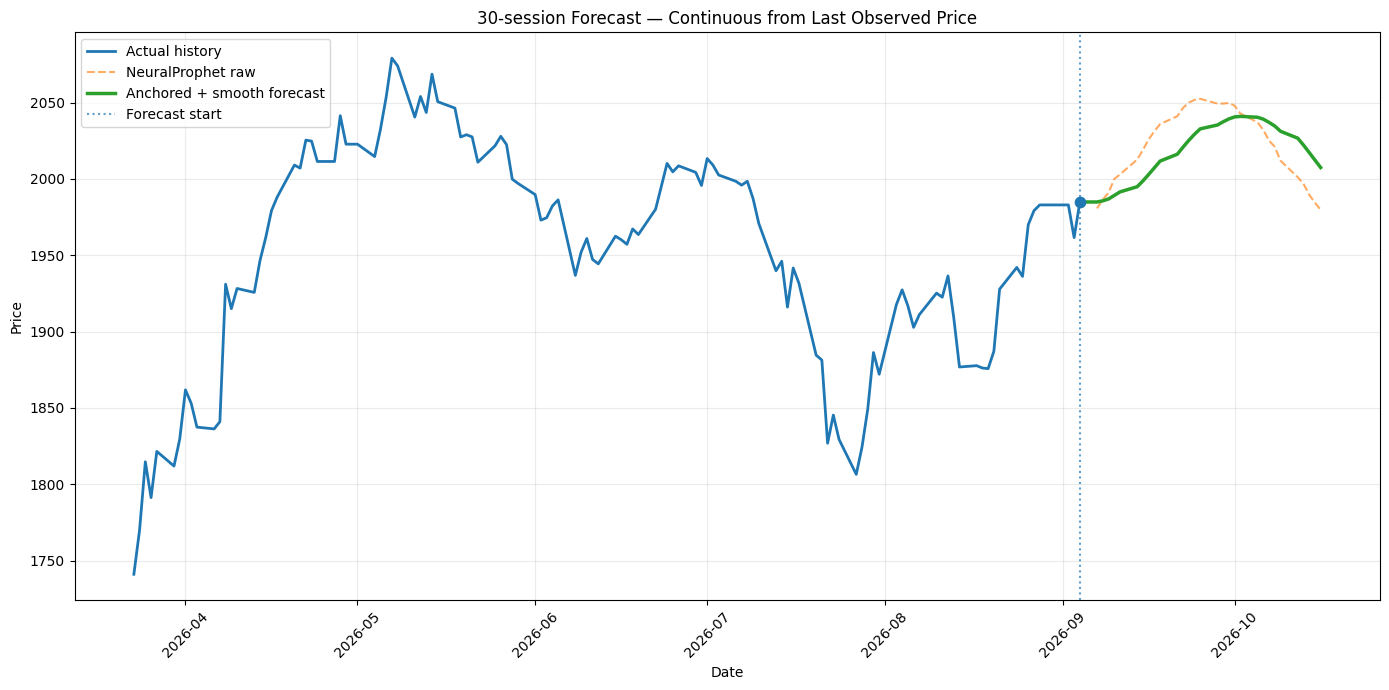

In [28]:

# ========== BIỂU ĐỒ: HISTORY + RAW + SMOOTH/ANCHORED ==========
import matplotlib.pyplot as plt

lookback = min(120, len(df))
hist_plot = df.tail(lookback).copy()

# Thêm đúng điểm cuối lịch sử vào đường smooth để nhìn continuity rõ ràng
anchor_point = pd.DataFrame({
    "ds": [df["ds"].iloc[-1]],
    "yhat_smooth": [df["y"].iloc[-1]]
})
smooth_plot = pd.concat(
    [anchor_point, forecast_path[["ds", "yhat_smooth"]]],
    ignore_index=True
)

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(hist_plot["ds"], hist_plot["y"], label="Actual history", linewidth=2)
ax.plot(forecast_path["ds"], forecast_path["yhat_raw"], label="NeuralProphet raw", linestyle="--", alpha=0.65)
ax.plot(smooth_plot["ds"], smooth_plot["yhat_smooth"], label="Anchored + smooth forecast", linewidth=2.5)

ax.axvline(df["ds"].iloc[-1], linestyle=":", alpha=0.7, label="Forecast start")
ax.scatter([df["ds"].iloc[-1]], [df["y"].iloc[-1]], s=55, zorder=5)

ax.set_title("30-session Forecast — Continuous from Last Observed Price")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
ax.grid(True, alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Kết quả:
  raw_mape: 9.7241
  smooth_mape: 5.7549
  raw_mae: 187.8838
  smooth_mae: 111.6327
  raw_rmse: 218.1714
  smooth_rmse: 138.1274


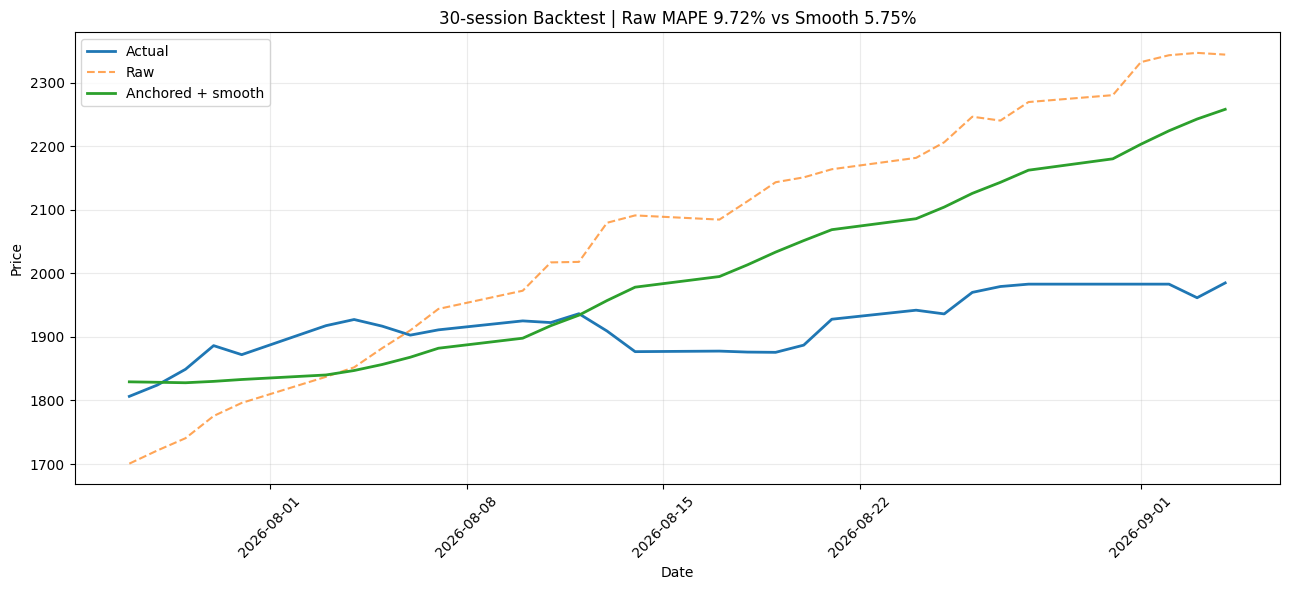

,ds,y,yhat_raw,yhat_smooth,error_pct_raw,error_pct_smooth
15,2026-08-17,1877.68,2084.447266,1994.921725,11.011848,6.243967
16,2026-08-18,1876.14,2113.333496,2013.331004,12.642633,7.312408
17,2026-08-19,1875.73,2143.205078,2033.351860,14.259786,8.403228
18,2026-08-20,1887.06,2150.858398,2051.418812,13.979333,8.709782
19,2026-08-21,1927.79,2163.632568,2068.615144,12.233831,7.305004
20,2026-08-24,1942.00,2181.548096,2085.860569,12.335123,7.407856
21,2026-08-25,1936.15,2206.034668,2104.148728,13.939244,8.676948
22,2026-08-26,1970.01,2246.230957,2125.697335,14.021297,7.902870
23,2026-08-27,1979.23,2240.155762,2143.056057,13.183196,8.277262
24,2026-08-28,1982.96,2269.305176,2162.165432,14.440290,9.037269


In [29]:

# ========== HIỂN THỊ BACKTEST ==========
if backtest_scores is not None and comparison_df is not None:
    import matplotlib.pyplot as plt

    print("Kết quả:")
    for k, v in backtest_scores.items():
        print(f"  {k}: {v:.4f}")

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(comparison_df["ds"], comparison_df["y"], label="Actual", linewidth=2)
    ax.plot(comparison_df["ds"], comparison_df["yhat_raw"], label="Raw", linestyle="--", alpha=0.7)
    ax.plot(comparison_df["ds"], comparison_df["yhat_smooth"], label="Anchored + smooth", linewidth=2)

    ax.set_title(
        f"30-session Backtest | Raw MAPE {backtest_scores['raw_mape']:.2f}% "
        f"vs Smooth {backtest_scores['smooth_mape']:.2f}%"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Price")
    ax.legend()
    ax.grid(True, alpha=0.25)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    display_cols = ["ds", "y", "yhat_raw", "yhat_smooth", "error_pct_raw", "error_pct_smooth"]
    display(comparison_df[display_cols].tail(15))
else:
    print("Chưa có kết quả backtest.")



## Vì sao bản này mượt hơn và nối sát ngày cuối?

Notebook cũ có `FORECAST_HORIZON = 90` dù phần mô tả/test đang nhắm tới 30 ngày. Với AR-Net, mỗi horizon là một đầu ra riêng; dự đoán 90 bước cùng lúc thường dễ tạo chênh lệch giữa `yhat1`, `yhat2`, ... hơn khi mục tiêu thực tế chỉ là 30 bước.

Bản này thay đổi theo 3 tầng:

1. **Model ổn định hơn:** horizon 30, `n_lags=120`, AR network nhỏ hơn, regularization mạnh hơn, seasonality nhẹ hơn.
2. **Continuity anchor:** khoảng cách giữa giá cuối thật và forecast đầu được hiệu chỉnh mạnh ở đầu horizon rồi giảm dần, nên không kéo sai toàn bộ 30 phiên.
3. **EMA + volatility cap:** làm giảm zig-zag nhưng vẫn để forecast phản ứng với hướng đi của model.

> `yhat_raw` vẫn được giữ nguyên để bạn kiểm tra model gốc.  
> `yhat_smooth` là đường nên dùng để hiển thị / đọc forecast nếu mục tiêu là đường dự đoán liên tục và ổn định.


In [30]:

# ========== CÁCH CHỈNH ĐỘ MƯỢT ==========
print("""
THAM SỐ QUAN TRỌNG trong anchor_and_smooth_forecast():

alpha:
  0.25 - 0.32 = rất mượt, phản ứng chậm
  0.35 - 0.45 = cân bằng (mặc định notebook = 0.38)
  0.50 - 0.65 = bám raw model nhiều hơn, ít smoothing

anchor_decay:
  5  = chỉ kéo sát điểm cuối trong vài phiên đầu
  8  = cân bằng
  12 = giữ ảnh hưởng của giá cuối lâu hơn

first_step_blend:
  0.15 = forecast ngày đầu rất sát giá cuối
  0.25 = mặc định
  0.40 = cho raw model nhiều quyền hơn ở ngày đầu

Nếu ưu tiên độ chính xác thay vì vẻ mượt:
=> luôn xem BACKTEST 'RAW vs SMOOTH' trước khi quyết định dùng yhat_smooth.
""")



THAM SỐ QUAN TRỌNG trong anchor_and_smooth_forecast():

alpha:
  0.25 - 0.32 = rất mượt, phản ứng chậm
  0.35 - 0.45 = cân bằng (mặc định notebook = 0.38)
  0.50 - 0.65 = bám raw model nhiều hơn, ít smoothing

anchor_decay:
  5  = chỉ kéo sát điểm cuối trong vài phiên đầu
  8  = cân bằng
  12 = giữ ảnh hưởng của giá cuối lâu hơn

first_step_blend:
  0.15 = forecast ngày đầu rất sát giá cuối
  0.25 = mặc định
  0.40 = cho raw model nhiều quyền hơn ở ngày đầu

Nếu ưu tiên độ chính xác thay vì vẻ mượt:
=> luôn xem BACKTEST 'RAW vs SMOOTH' trước khi quyết định dùng yhat_smooth.



In [31]:

# ========== DIAGNOSTIC: ĐỘ NỐI + ĐỘ RUNG ==========
def path_diagnostics(path_df, history_df):
    last_y = float(history_df["y"].iloc[-1])

    raw_first_gap = (path_df["yhat_raw"].iloc[0] / last_y - 1) * 100
    smooth_first_gap = (path_df["yhat_smooth"].iloc[0] / last_y - 1) * 100

    raw_abs_move = path_df["yhat_raw"].pct_change().abs().mean() * 100
    smooth_abs_move = path_df["yhat_smooth"].pct_change().abs().mean() * 100

    print("=" * 68)
    print("FORECAST CONTINUITY / SMOOTHNESS DIAGNOSTIC")
    print("=" * 68)
    print(f"Last actual price       : {last_y:.2f}")
    print(f"Raw first forecast      : {path_df['yhat_raw'].iloc[0]:.2f} ({raw_first_gap:+.2f}%)")
    print(f"Smooth first forecast   : {path_df['yhat_smooth'].iloc[0]:.2f} ({smooth_first_gap:+.2f}%)")
    print(f"Avg |daily move| raw    : {raw_abs_move:.3f}%")
    print(f"Avg |daily move| smooth : {smooth_abs_move:.3f}%")
    print("=" * 68)

path_diagnostics(forecast_path, df)


FORECAST CONTINUITY / SMOOTHNESS DIAGNOSTIC
Last actual price       : 1984.89
Raw first forecast      : 1980.70 (-0.21%)
Smooth first forecast   : 1984.89 (-0.00%)
Avg |daily move| raw    : 0.248%
Avg |daily move| smooth : 0.153%


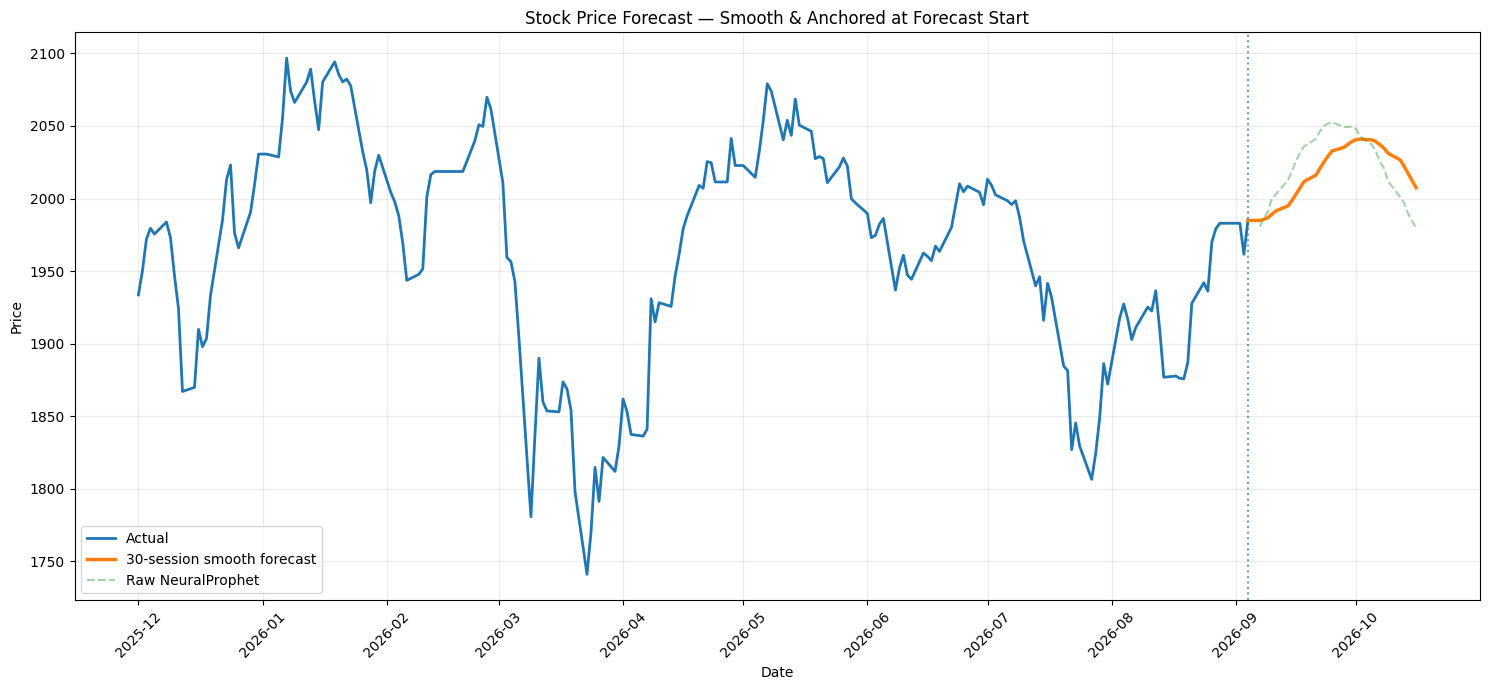

In [32]:

# ========== BIỂU ĐỒ CUỐI: 200 PHIÊN LỊCH SỬ + 30 PHIÊN FORECAST ==========
import matplotlib.pyplot as plt

hist_plot = df.tail(min(200, len(df))).copy()

continuous_forecast = pd.concat([
    pd.DataFrame({
        "ds": [df["ds"].iloc[-1]],
        "yhat_smooth": [df["y"].iloc[-1]]
    }),
    forecast_path[["ds", "yhat_smooth"]]
], ignore_index=True)

fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(hist_plot["ds"], hist_plot["y"], label="Actual", linewidth=2)
ax.plot(continuous_forecast["ds"], continuous_forecast["yhat_smooth"],
        label="30-session smooth forecast", linewidth=2.5)
ax.plot(forecast_path["ds"], forecast_path["yhat_raw"],
        label="Raw NeuralProphet", linestyle="--", alpha=0.45)

ax.axvline(df["ds"].iloc[-1], linestyle=":", alpha=0.7)
ax.set_title("Stock Price Forecast — Smooth & Anchored at Forecast Start")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
ax.grid(True, alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [33]:

# ========== BẢNG DỰ ĐOÁN 30 PHIÊN TIẾP THEO ==========
last_train_date = pd.to_datetime(df["ds"].max())
last_train_price = float(df.loc[df["ds"].idxmax(), "y"])

print(f"Ngày cuối dữ liệu : {last_train_date.date()}")
print(f"Giá cuối dữ liệu  : {last_train_price:.2f}")
print(f"Số bước forecast  : {len(forecast_path)} phiên")
print()

results_30d = forecast_path[["ds", "yhat_raw", "yhat_smooth"]].copy()
results_30d["change_from_last_pct"] = (
    results_30d["yhat_smooth"] / last_train_price - 1
) * 100
results_30d["ds"] = pd.to_datetime(results_30d["ds"]).dt.date

print(results_30d.to_string(
    index=False,
    formatters={
        "yhat_raw": "{:.2f}".format,
        "yhat_smooth": "{:.2f}".format,
        "change_from_last_pct": "{:+.2f}%".format,
    }
))


Ngày cuối dữ liệu : 2026-09-04
Giá cuối dữ liệu  : 1984.89
Số bước forecast  : 30 phiên

        ds yhat_raw yhat_smooth change_from_last_pct
2026-09-07  1980.70     1984.89               -0.00%
2026-09-08  1986.53     1985.64               +0.04%
2026-09-09  1990.95     1986.85               +0.10%
2026-09-10  1999.99     1989.15               +0.21%
2026-09-11  2002.95     1991.49               +0.33%
2026-09-14  2012.68     1994.89               +0.50%
2026-09-15  2018.96     1998.69               +0.70%
2026-09-16  2025.85     2002.91               +0.91%
2026-09-17  2031.22     2007.29               +1.13%
2026-09-18  2035.91     2011.68               +1.35%
2026-09-21  2041.10     2016.18               +1.58%
2026-09-22  2046.48     2020.80               +1.81%
2026-09-23  2050.02     2025.25               +2.03%
2026-09-24  2051.72     2029.27               +2.24%
2026-09-25  2052.45     2032.79               +2.41%
2026-09-28  2049.33     2035.30               +2.54%
2026-09-29